In [5]:
# Step 1: Import all necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score, precision_score, recall_score, 
                             f1_score, confusion_matrix, classification_report)
import warnings
warnings.filterwarnings('ignore')

# Set display options for better readability
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)

print("✓ All libraries imported successfully!")

# Load the dataset
# If you uploaded the CSV file to Kaggle, use this:
df = pd.read_csv('/kaggle/input/web-page-phishing-detection-dataset/dataset_phishing.csv')

# Or if the dataset is in a different location, adjust the path accordingly
# df = pd.read_csv('your_file_path.csv')

print("\n✓ Dataset loaded successfully!")
print(f"Dataset shape: {df.shape}")
print(f"Number of rows: {df.shape[0]}")
print(f"Number of columns: {df.shape[1]}")

✓ All libraries imported successfully!

✓ Dataset loaded successfully!
Dataset shape: (11430, 89)
Number of rows: 11430
Number of columns: 89


FIRST 5 ROWS OF THE DATASET
                                                 url  length_url  \
0              http://www.crestonwood.com/router.php          37   
1  http://shadetreetechnology.com/V4/validation/a...          77   
2  https://support-appleld.com.secureupdate.duila...         126   
3                                 http://rgipt.ac.in          18   
4  http://www.iracing.com/tracks/gateway-motorspo...          55   

   length_hostname  ip  nb_dots  nb_hyphens  nb_at  nb_qm  nb_and  nb_or  \
0               19   0        3           0      0      0       0      0   
1               23   1        1           0      0      0       0      0   
2               50   1        4           1      0      1       2      0   
3               11   0        2           0      0      0       0      0   
4               15   0        2           2      0      0       0      0   

   nb_eq  nb_underscore  nb_tilde  nb_percent  nb_slash  nb_star  nb_colon  \
0      0              0     

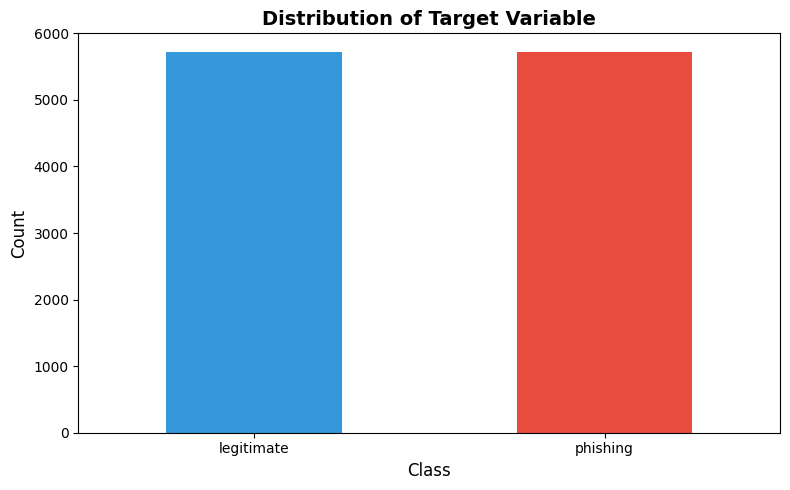


✓ Data Exploration Complete!


In [6]:
# Step 2: Data Exploration

# Display first few rows
print("=" * 80)
print("FIRST 5 ROWS OF THE DATASET")
print("=" * 80)
print(df.head())

# Display dataset information
print("\n" + "=" * 80)
print("DATASET INFORMATION")
print("=" * 80)
print(df.info())

# Check column names
print("\n" + "=" * 80)
print("COLUMN NAMES")
print("=" * 80)
print(df.columns.tolist())

# Check for missing values
print("\n" + "=" * 80)
print("MISSING VALUES")
print("=" * 80)
missing_values = df.isnull().sum()
if missing_values.sum() == 0:
    print("✓ No missing values found!")
else:
    print(missing_values[missing_values > 0])

# Check for duplicate rows
print("\n" + "=" * 80)
print("DUPLICATE ROWS")
print("=" * 80)
duplicates = df.duplicated().sum()
print(f"Number of duplicate rows: {duplicates}")
if duplicates > 0:
    print("⚠ Warning: Duplicates found and will be removed in preprocessing")
else:
    print("✓ No duplicate rows found!")

# Check data types
print("\n" + "=" * 80)
print("DATA TYPES SUMMARY")
print("=" * 80)
print(df.dtypes.value_counts())

# Statistical summary
print("\n" + "=" * 80)
print("STATISTICAL SUMMARY (First 10 columns)")
print("=" * 80)
print(df.describe().iloc[:, :10])

# Check the target variable (usually 'status' or 'label' or last column)
print("\n" + "=" * 80)
print("TARGET VARIABLE ANALYSIS")
print("=" * 80)

# Try to identify the target column
possible_target_names = ['status', 'label', 'class', 'target', 'phishing']
target_col = None

for col in possible_target_names:
    if col in df.columns:
        target_col = col
        break

# If not found, assume it's the last column
if target_col is None:
    target_col = df.columns[-1]
    
print(f"Target column identified: '{target_col}'")
print(f"\nClass distribution:")
print(df[target_col].value_counts())
print(f"\nClass percentages:")
print(df[target_col].value_counts(normalize=True) * 100)

# Visualize class distribution
plt.figure(figsize=(8, 5))
df[target_col].value_counts().plot(kind='bar', color=['#3498db', '#e74c3c'])
plt.title('Distribution of Target Variable', fontsize=14, fontweight='bold')
plt.xlabel('Class', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

print("\n" + "=" * 80)
print("✓ Data Exploration Complete!")
print("=" * 80)

In [7]:
# Step 3: Data Preprocessing

print("=" * 80)
print("DATA PREPROCESSING")
print("=" * 80)

# 1. Remove the 'url' column (not needed for prediction)
print("\n1. Removing 'url' column (text data, not useful for ML)...")
df_processed = df.drop('url', axis=1)
print(f"   ✓ Columns after removal: {df_processed.shape[1]}")

# 2. Separate features and target
print("\n2. Separating features (X) and target (y)...")
X = df_processed.drop('status', axis=1)
y = df_processed['status']
print(f"   ✓ Features shape: {X.shape}")
print(f"   ✓ Target shape: {y.shape}")

# 3. Encode target variable (convert 'legitimate'/'phishing' to 0/1)
print("\n3. Encoding target variable...")
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)
print(f"   ✓ Encoding mapping: {dict(zip(label_encoder.classes_, label_encoder.transform(label_encoder.classes_)))}")
print(f"   ✓ Example: 'legitimate' → {label_encoder.transform(['legitimate'])[0]}, 'phishing' → {label_encoder.transform(['phishing'])[0]}")

# 4. Check if there are any categorical features (should be none in this dataset)
print("\n4. Checking for categorical features...")
categorical_cols = X.select_dtypes(include=['object']).columns.tolist()
if len(categorical_cols) == 0:
    print("   ✓ No categorical features found (all numeric)")
else:
    print(f"   ⚠ Categorical features found: {categorical_cols}")

# 5. Split the dataset into training (80%) and testing (20%) sets
print("\n5. Splitting dataset into training and testing sets...")
X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded, 
    test_size=0.2,      # 20% for testing
    random_state=42,    # For reproducibility
    stratify=y_encoded  # Maintain class balance in both sets
)
print(f"   ✓ Training set size: {X_train.shape[0]} samples ({X_train.shape[0]/len(X)*100:.1f}%)")
print(f"   ✓ Testing set size: {X_test.shape[0]} samples ({X_test.shape[0]/len(X)*100:.1f}%)")
print(f"   ✓ Number of features: {X_train.shape[1]}")

# 6. Feature Scaling (important for KNN and SVM)
print("\n6. Scaling features using StandardScaler...")
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)  # Fit on training data only
X_test_scaled = scaler.transform(X_test)        # Transform test data using training statistics
print("   ✓ Features scaled (mean=0, std=1)")
print(f"   ✓ Training data scaled shape: {X_train_scaled.shape}")
print(f"   ✓ Testing data scaled shape: {X_test_scaled.shape}")

# 7. Verify class distribution in train and test sets
print("\n7. Verifying class distribution after split...")
unique_train, counts_train = np.unique(y_train, return_counts=True)
unique_test, counts_test = np.unique(y_test, return_counts=True)

print("   Training set distribution:")
for cls, count in zip(unique_train, counts_train):
    class_name = label_encoder.inverse_transform([cls])[0]
    print(f"      {class_name}: {count} ({count/len(y_train)*100:.1f}%)")

print("   Testing set distribution:")
for cls, count in zip(unique_test, counts_test):
    class_name = label_encoder.inverse_transform([cls])[0]
    print(f"      {class_name}: {count} ({count/len(y_test)*100:.1f}%)")

print("\n" + "=" * 80)
print("✓ PREPROCESSING COMPLETE!")
print("=" * 80)
print(f"\nReady for model training:")
print(f"  • Training samples: {X_train_scaled.shape[0]}")
print(f"  • Testing samples: {X_test_scaled.shape[0]}")
print(f"  • Features: {X_train_scaled.shape[1]}")
print(f"  • Classes: 2 (legitimate vs phishing)")

DATA PREPROCESSING

1. Removing 'url' column (text data, not useful for ML)...
   ✓ Columns after removal: 88

2. Separating features (X) and target (y)...
   ✓ Features shape: (11430, 87)
   ✓ Target shape: (11430,)

3. Encoding target variable...
   ✓ Encoding mapping: {'legitimate': 0, 'phishing': 1}
   ✓ Example: 'legitimate' → 0, 'phishing' → 1

4. Checking for categorical features...
   ✓ No categorical features found (all numeric)

5. Splitting dataset into training and testing sets...
   ✓ Training set size: 9144 samples (80.0%)
   ✓ Testing set size: 2286 samples (20.0%)
   ✓ Number of features: 87

6. Scaling features using StandardScaler...
   ✓ Features scaled (mean=0, std=1)
   ✓ Training data scaled shape: (9144, 87)
   ✓ Testing data scaled shape: (2286, 87)

7. Verifying class distribution after split...
   Training set distribution:
      legitimate: 4572 (50.0%)
      phishing: 4572 (50.0%)
   Testing set distribution:
      legitimate: 1143 (50.0%)
      phishing: 11

In [9]:
# Step 4: Model Training (8 Models)

print("=" * 80)
print("TRAINING CLASSIFICATION MODELS (8 MODELS)")
print("=" * 80)

# Import additional models
from sklearn.ensemble import GradientBoostingClassifier, AdaBoostClassifier

# Dictionary to store trained models
models = {}

# 1. k-Nearest Neighbors (KNN)
print("\n1. Training k-Nearest Neighbors (KNN)...")
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train_scaled, y_train)
models['KNN'] = knn
print("   ✓ KNN model trained successfully")

# 2. Naïve Bayes
print("\n2. Training Naïve Bayes...")
nb = GaussianNB()
nb.fit(X_train_scaled, y_train)
models['Naive Bayes'] = nb
print("   ✓ Naïve Bayes model trained successfully")

# 3. Decision Tree
print("\n3. Training Decision Tree...")
dt = DecisionTreeClassifier(random_state=42, max_depth=10)
dt.fit(X_train_scaled, y_train)
models['Decision Tree'] = dt
print("   ✓ Decision Tree model trained successfully")

# 4. Support Vector Machine (SVM)
print("\n4. Training Support Vector Machine (SVM)...")
print("   (This may take a minute...)")
svm = SVC(kernel='rbf', random_state=42)
svm.fit(X_train_scaled, y_train)
models['SVM'] = svm
print("   ✓ SVM model trained successfully")

# 5. Random Forest
print("\n5. Training Random Forest...")
rf = RandomForestClassifier(n_estimators=100, random_state=42, max_depth=15)
rf.fit(X_train_scaled, y_train)
models['Random Forest'] = rf
print("   ✓ Random Forest model trained successfully")

# 6. Logistic Regression
print("\n6. Training Logistic Regression...")
lr = LogisticRegression(random_state=42, max_iter=1000)
lr.fit(X_train_scaled, y_train)
models['Logistic Regression'] = lr
print("   ✓ Logistic Regression model trained successfully")

# 7. Gradient Boosting (NEW)
print("\n7. Training Gradient Boosting...")
print("   (This may take a minute...)")
gb = GradientBoostingClassifier(n_estimators=100, random_state=42, max_depth=5)
gb.fit(X_train_scaled, y_train)
models['Gradient Boosting'] = gb
print("   ✓ Gradient Boosting model trained successfully")

# 8. AdaBoost (NEW)
print("\n8. Training AdaBoost...")
ada = AdaBoostClassifier(n_estimators=100, random_state=42)
ada.fit(X_train_scaled, y_train)
models['AdaBoost'] = ada
print("   ✓ AdaBoost model trained successfully")

print("\n" + "=" * 80)
print("✓ ALL 8 MODELS TRAINED SUCCESSFULLY!")
print("=" * 80)
print(f"\nTotal models trained: {len(models)}")
print(f"Models: {list(models.keys())}")

# Quick prediction test on training data
print("\n" + "=" * 80)
print("QUICK TRAINING ACCURACY CHECK")
print("=" * 80)
for name, model in models.items():
    train_pred = model.predict(X_train_scaled)
    train_accuracy = accuracy_score(y_train, train_pred)
    print(f"{name:25s} Training Accuracy: {train_accuracy:.4f} ({train_accuracy*100:.2f}%)")

print("\n✓ Ready for comprehensive evaluation!")

TRAINING CLASSIFICATION MODELS (8 MODELS)

1. Training k-Nearest Neighbors (KNN)...
   ✓ KNN model trained successfully

2. Training Naïve Bayes...
   ✓ Naïve Bayes model trained successfully

3. Training Decision Tree...
   ✓ Decision Tree model trained successfully

4. Training Support Vector Machine (SVM)...
   (This may take a minute...)
   ✓ SVM model trained successfully

5. Training Random Forest...
   ✓ Random Forest model trained successfully

6. Training Logistic Regression...
   ✓ Logistic Regression model trained successfully

7. Training Gradient Boosting...
   (This may take a minute...)
   ✓ Gradient Boosting model trained successfully

8. Training AdaBoost...
   ✓ AdaBoost model trained successfully

✓ ALL 8 MODELS TRAINED SUCCESSFULLY!

Total models trained: 8
Models: ['KNN', 'Naive Bayes', 'Decision Tree', 'SVM', 'Random Forest', 'Logistic Regression', 'Gradient Boosting', 'AdaBoost']

QUICK TRAINING ACCURACY CHECK
KNN                       Training Accuracy: 0.9567 (

In [10]:
# Step 5: Model Evaluation with Cross-Validation

print("=" * 80)
print("MODEL EVALUATION WITH CROSS-VALIDATION")
print("=" * 80)

# 1. Cross-Validation on Training Set (k=5 fold)
print("\n1. Performing 5-Fold Cross-Validation on Training Set...")
print("-" * 80)

kfold = KFold(n_splits=5, shuffle=True, random_state=42)
cv_results = {}

for name, model in models.items():
    # Perform cross-validation
    cv_scores = cross_val_score(model, X_train_scaled, y_train, cv=kfold, scoring='accuracy')
    cv_results[name] = cv_scores
    
    print(f"\n{name}:")
    print(f"  CV Scores: {cv_scores}")
    print(f"  Mean CV Accuracy: {cv_scores.mean():.4f} ({cv_scores.mean()*100:.2f}%)")
    print(f"  Std Deviation: {cv_scores.std():.4f}")

# 2. Predictions on Test Set
print("\n" + "=" * 80)
print("2. Making Predictions on Test Set...")
print("-" * 80)

predictions = {}
for name, model in models.items():
    y_pred = model.predict(X_test_scaled)
    predictions[name] = y_pred
    print(f"✓ {name} predictions completed")

# 3. Calculate Evaluation Metrics
print("\n" + "=" * 80)
print("3. Calculating Evaluation Metrics...")
print("-" * 80)

results_data = []

for name in models.keys():
    y_pred = predictions[name]
    
    # Calculate metrics
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, average='binary')
    recall = recall_score(y_test, y_pred, average='binary')
    f1 = f1_score(y_test, y_pred, average='binary')
    
    # Cross-validation mean
    cv_mean = cv_results[name].mean()
    
    results_data.append({
        'Model': name,
        'CV Accuracy': cv_mean,
        'Test Accuracy': accuracy,
        'Precision': precision,
        'Recall': recall,
        'F1-Score': f1
    })

# Create results DataFrame
results_df = pd.DataFrame(results_data)
results_df = results_df.sort_values('Test Accuracy', ascending=False).reset_index(drop=True)

print("\n" + "=" * 80)
print("EVALUATION METRICS SUMMARY (Sorted by Test Accuracy)")
print("=" * 80)
print(results_df.to_string(index=False))

# 4. Find the best model
print("\n" + "=" * 80)
print("BEST MODEL IDENTIFICATION")
print("=" * 80)

best_model_name = results_df.iloc[0]['Model']
best_accuracy = results_df.iloc[0]['Test Accuracy']
best_f1 = results_df.iloc[0]['F1-Score']

print(f"\n🏆 Best Model: {best_model_name}")
print(f"   • Test Accuracy: {best_accuracy:.4f} ({best_accuracy*100:.2f}%)")
print(f"   • F1-Score: {best_f1:.4f}")
print(f"   • Precision: {results_df.iloc[0]['Precision']:.4f}")
print(f"   • Recall: {results_df.iloc[0]['Recall']:.4f}")

print("\n✓ Evaluation complete! Ready for confusion matrices...")

MODEL EVALUATION WITH CROSS-VALIDATION

1. Performing 5-Fold Cross-Validation on Training Set...
--------------------------------------------------------------------------------

KNN:
  CV Scores: [0.93165664 0.93767086 0.94204483 0.92728267 0.93599562]
  Mean CV Accuracy: 0.9349 (93.49%)
  Std Deviation: 0.0051

Naive Bayes:
  CV Scores: [0.68288682 0.69382176 0.68124658 0.67577911 0.68380744]
  Mean CV Accuracy: 0.6835 (68.35%)
  Std Deviation: 0.0059

Decision Tree:
  CV Scores: [0.93548387 0.93548387 0.94423182 0.94259158 0.93599562]
  Mean CV Accuracy: 0.9388 (93.88%)
  Std Deviation: 0.0038

SVM:
  CV Scores: [0.956807   0.956807   0.95790049 0.95297977 0.95787746]
  Mean CV Accuracy: 0.9565 (95.65%)
  Std Deviation: 0.0018

Random Forest:
  CV Scores: [0.96719519 0.9650082  0.96555495 0.96446145 0.96115974]
  Mean CV Accuracy: 0.9647 (96.47%)
  Std Deviation: 0.0020

Logistic Regression:
  CV Scores: [0.94587206 0.94587206 0.95188628 0.94095134 0.9463895 ]
  Mean CV Accuracy: 0.

CONFUSION MATRICES FOR ALL MODELS

KNN:
  Confusion Matrix:
    True Negatives (TN):  1092 | True Positives (TP):  1056
    False Positives (FP):   51 | False Negatives (FN):   87

Naive Bayes:
  Confusion Matrix:
    True Negatives (TN):  1115 | True Positives (TP):   458
    False Positives (FP):   28 | False Negatives (FN):  685

Decision Tree:
  Confusion Matrix:
    True Negatives (TN):  1074 | True Positives (TP):  1068
    False Positives (FP):   69 | False Negatives (FN):   75

SVM:
  Confusion Matrix:
    True Negatives (TN):  1095 | True Positives (TP):  1086
    False Positives (FP):   48 | False Negatives (FN):   57

Random Forest:
  Confusion Matrix:
    True Negatives (TN):  1095 | True Positives (TP):  1104
    False Positives (FP):   48 | False Negatives (FN):   39

Logistic Regression:
  Confusion Matrix:
    True Negatives (TN):  1074 | True Positives (TP):  1066
    False Positives (FP):   69 | False Negatives (FN):   77

Gradient Boosting:
  Confusion Matrix:
    Tr

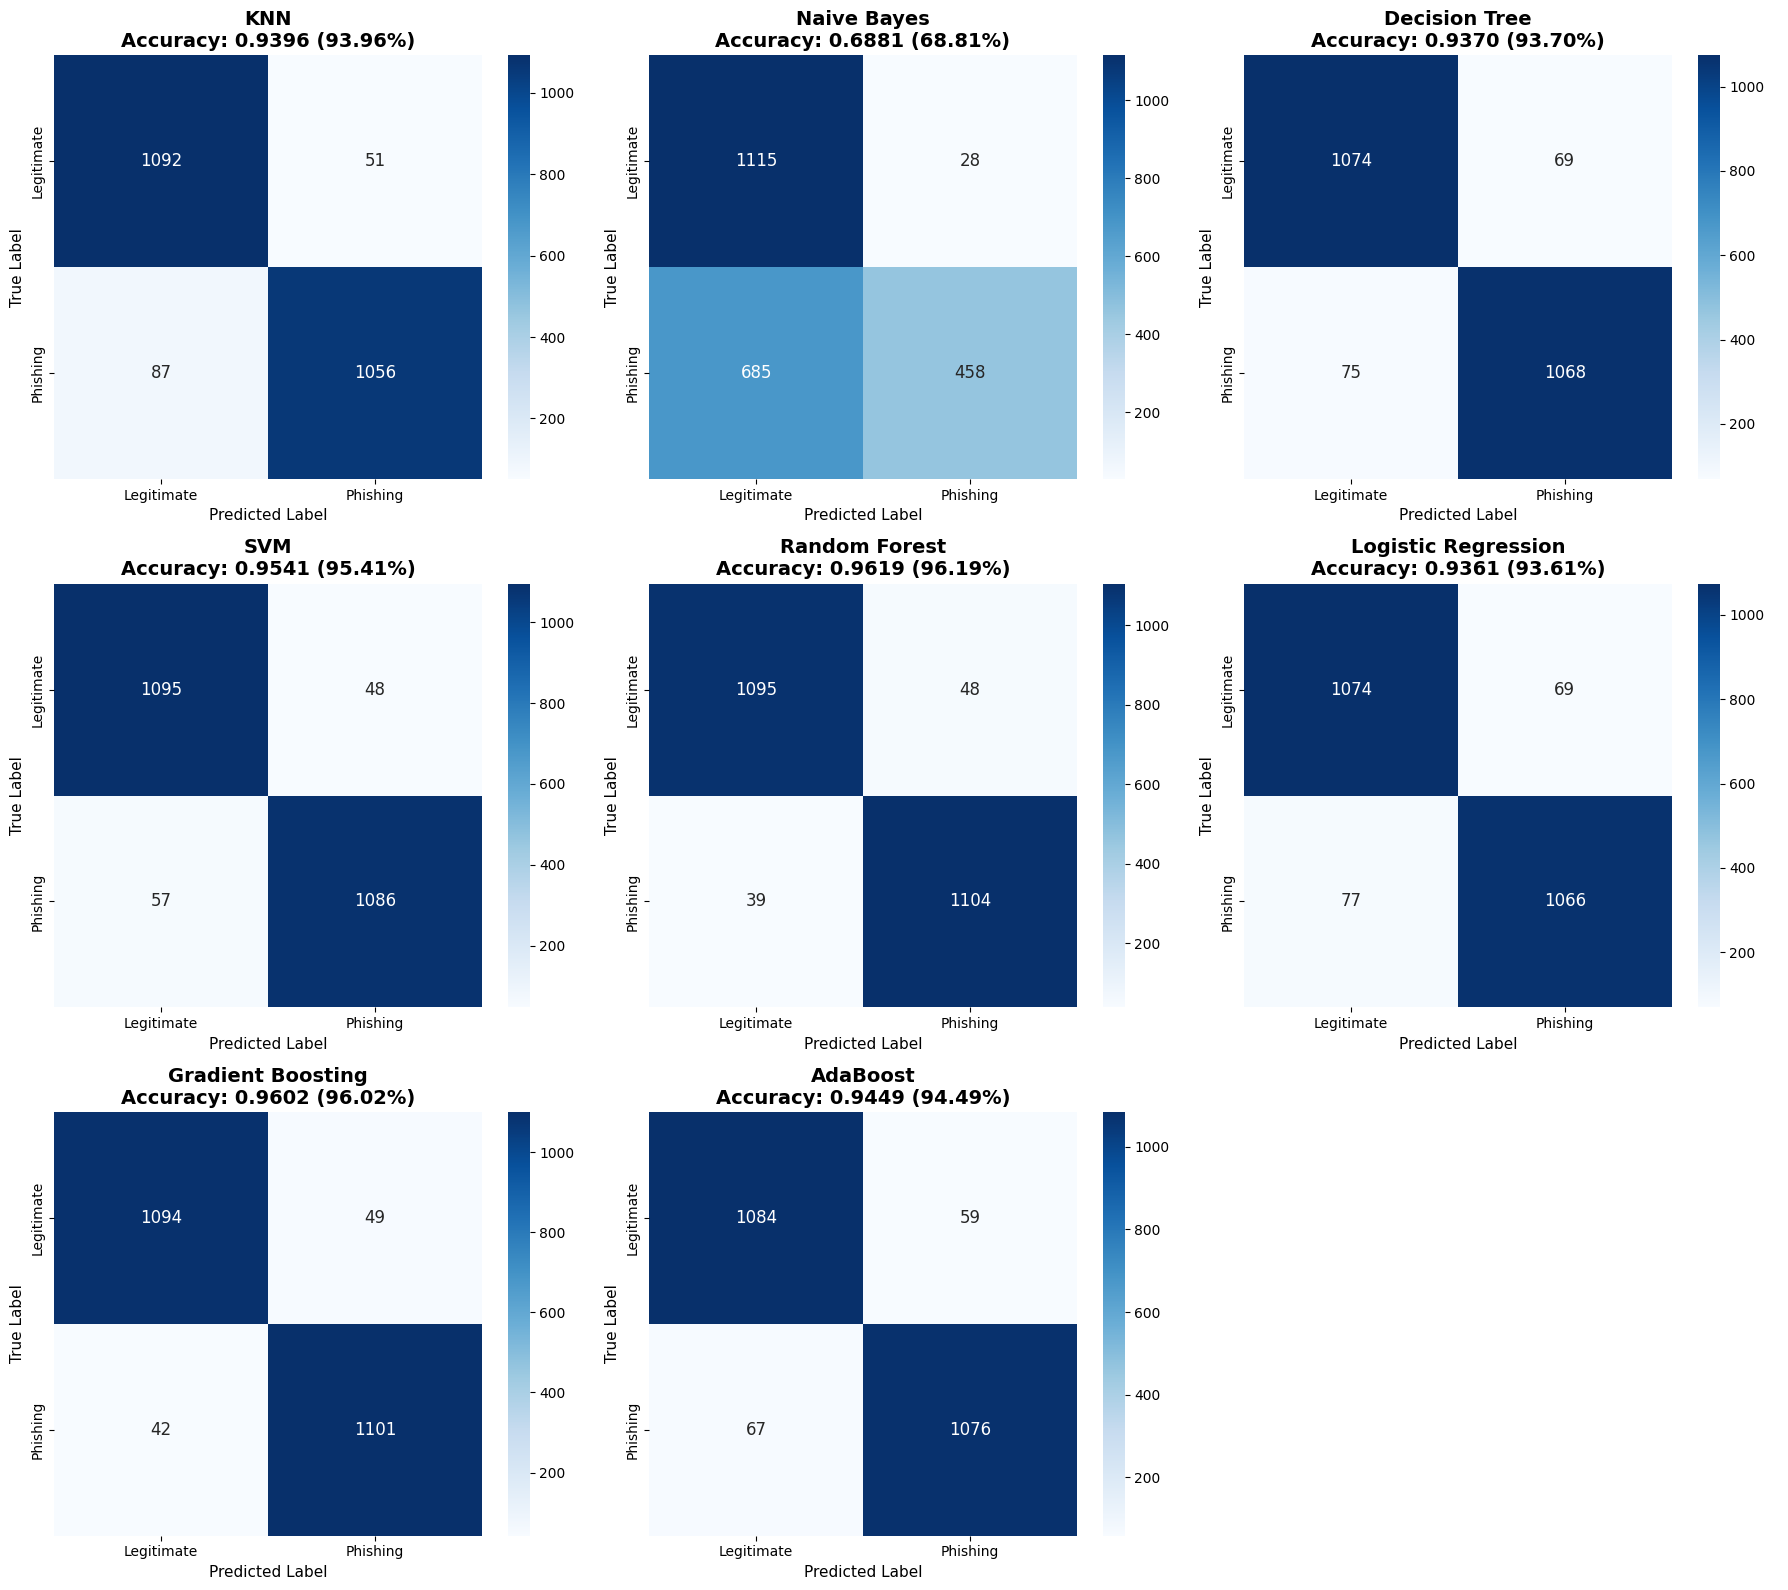


✓ Confusion matrices generated successfully!


In [11]:
# Step 6: Confusion Matrices Visualization

print("=" * 80)
print("CONFUSION MATRICES FOR ALL MODELS")
print("=" * 80)

# Create a large figure with subplots for all 8 models
fig, axes = plt.subplots(3, 3, figsize=(18, 16))
axes = axes.ravel()  # Flatten the 2D array of axes

# Class labels
class_labels = ['Legitimate', 'Phishing']

# Plot confusion matrix for each model
for idx, (name, model) in enumerate(models.items()):
    y_pred = predictions[name]
    cm = confusion_matrix(y_test, y_pred)
    
    # Plot
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=class_labels, yticklabels=class_labels,
                ax=axes[idx], cbar=True, annot_kws={"size": 12})
    
    # Get accuracy for this model
    accuracy = accuracy_score(y_test, y_pred)
    
    axes[idx].set_title(f'{name}\nAccuracy: {accuracy:.4f} ({accuracy*100:.2f}%)', 
                       fontsize=14, fontweight='bold')
    axes[idx].set_ylabel('True Label', fontsize=11)
    axes[idx].set_xlabel('Predicted Label', fontsize=11)
    
    # Print detailed confusion matrix info
    print(f"\n{name}:")
    print(f"  Confusion Matrix:")
    print(f"    True Negatives (TN):  {cm[0,0]:4d} | True Positives (TP):  {cm[1,1]:4d}")
    print(f"    False Positives (FP): {cm[0,1]:4d} | False Negatives (FN): {cm[1,0]:4d}")

# Hide the last subplot (we have 8 models but 9 subplots in 3x3 grid)
axes[8].axis('off')

plt.tight_layout()
plt.show()

print("\n" + "=" * 80)
print("✓ Confusion matrices generated successfully!")
print("=" * 80)

CREATING COMPREHENSIVE VISUALIZATIONS


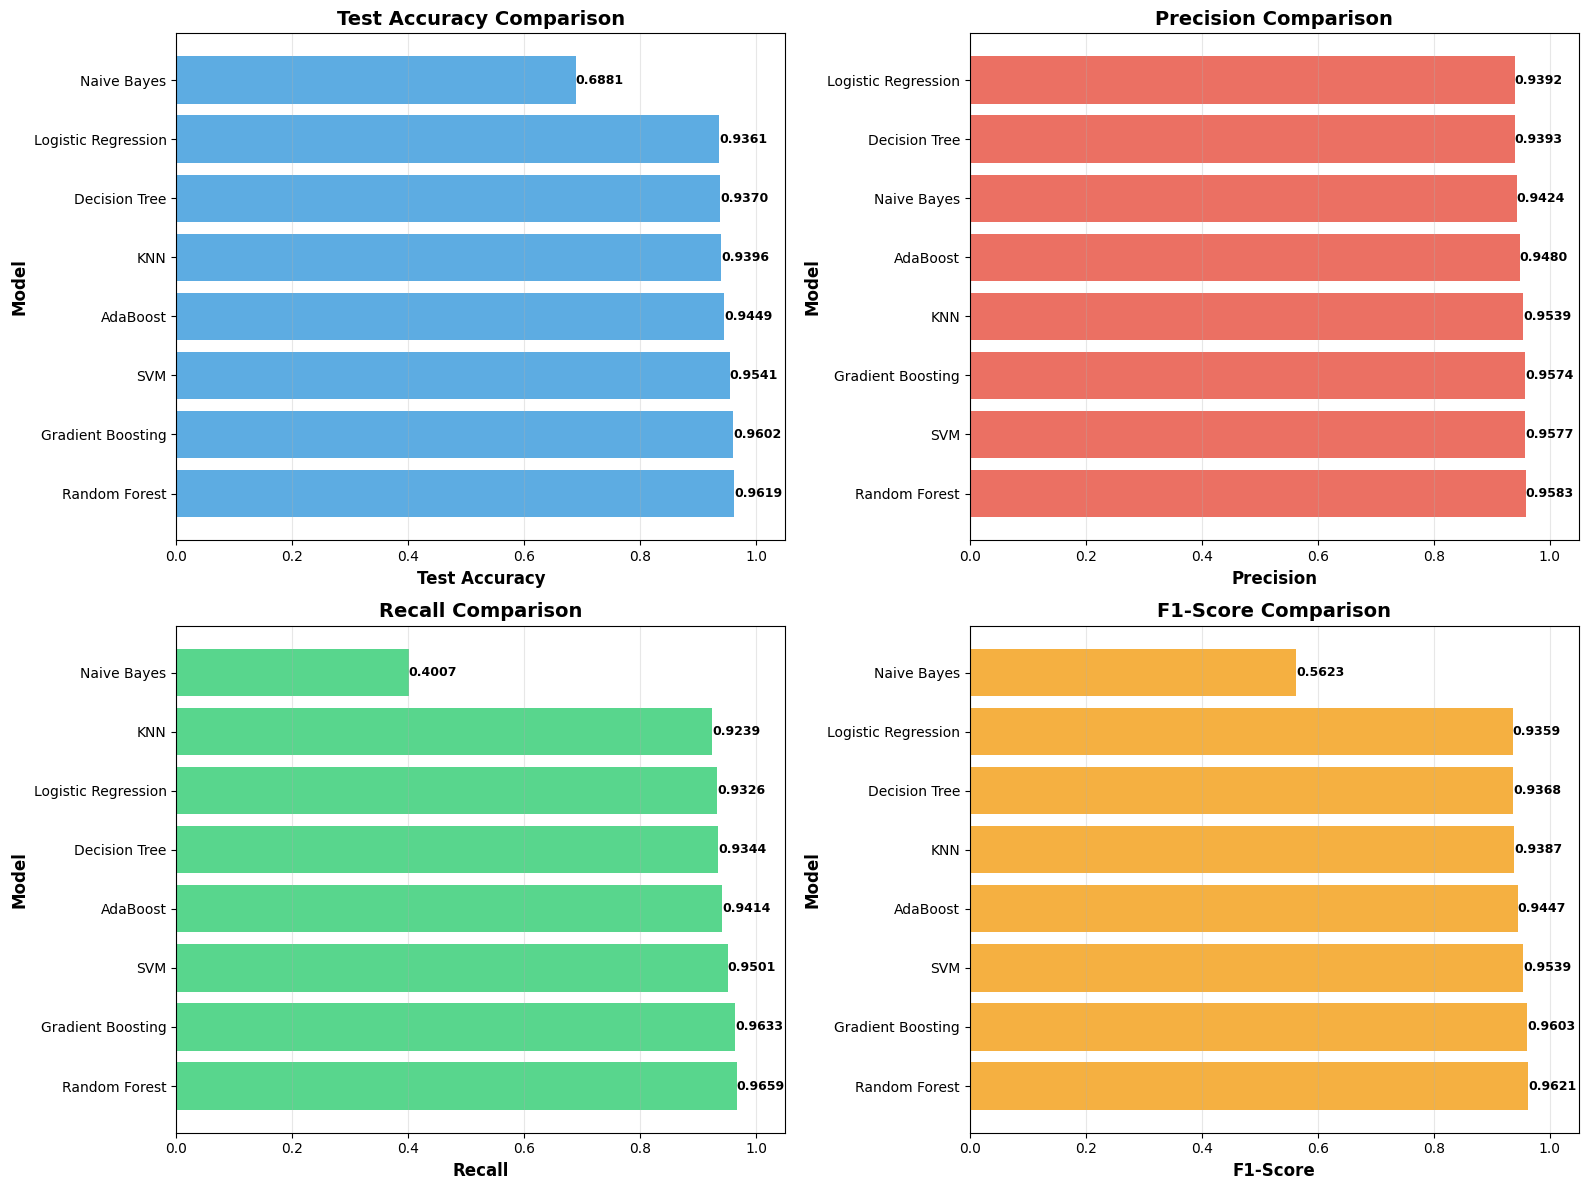

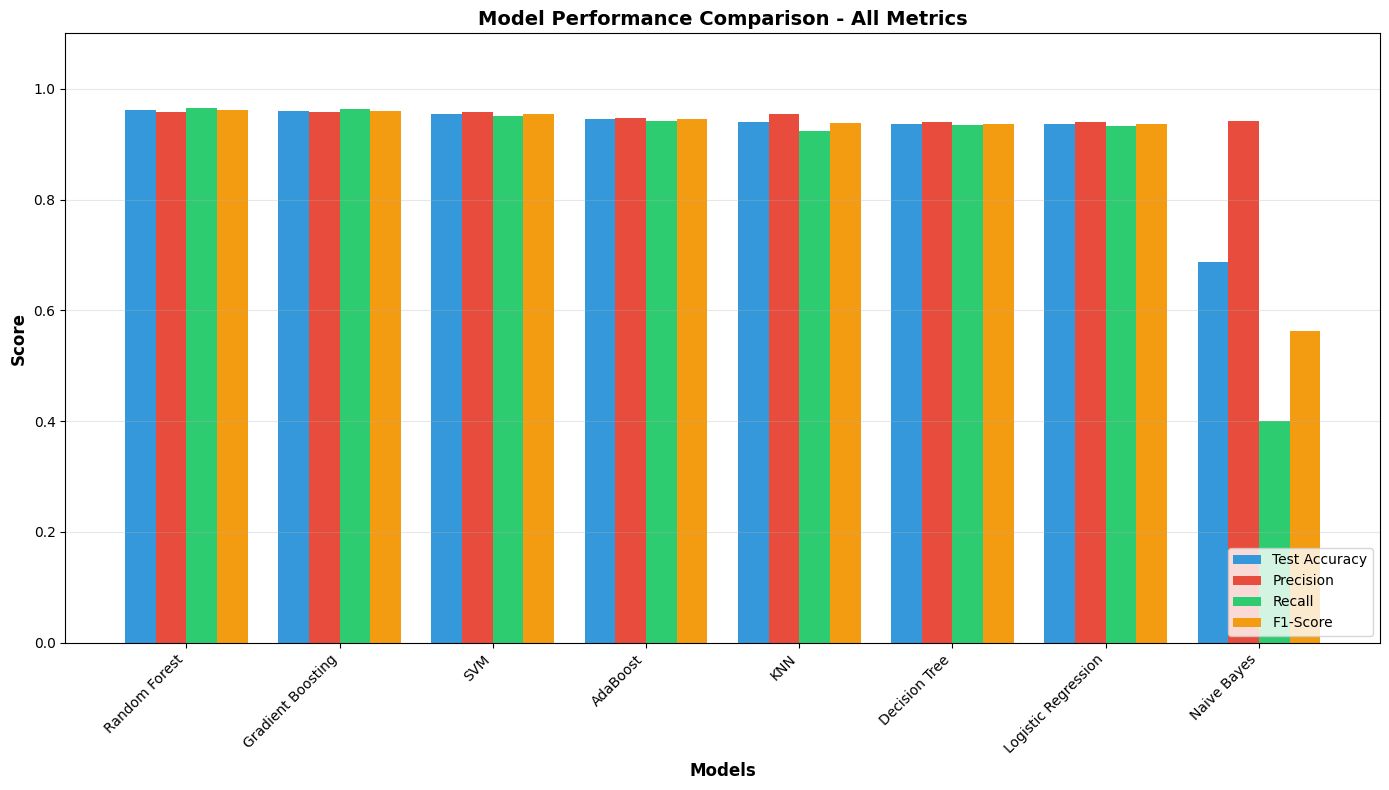

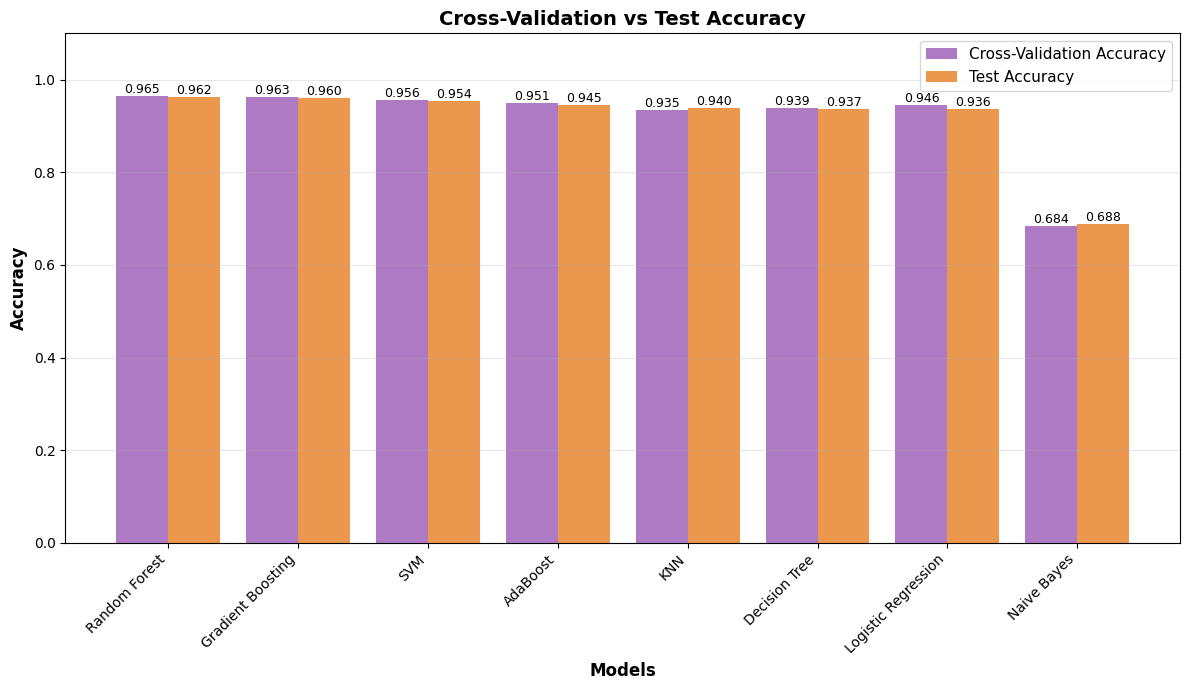

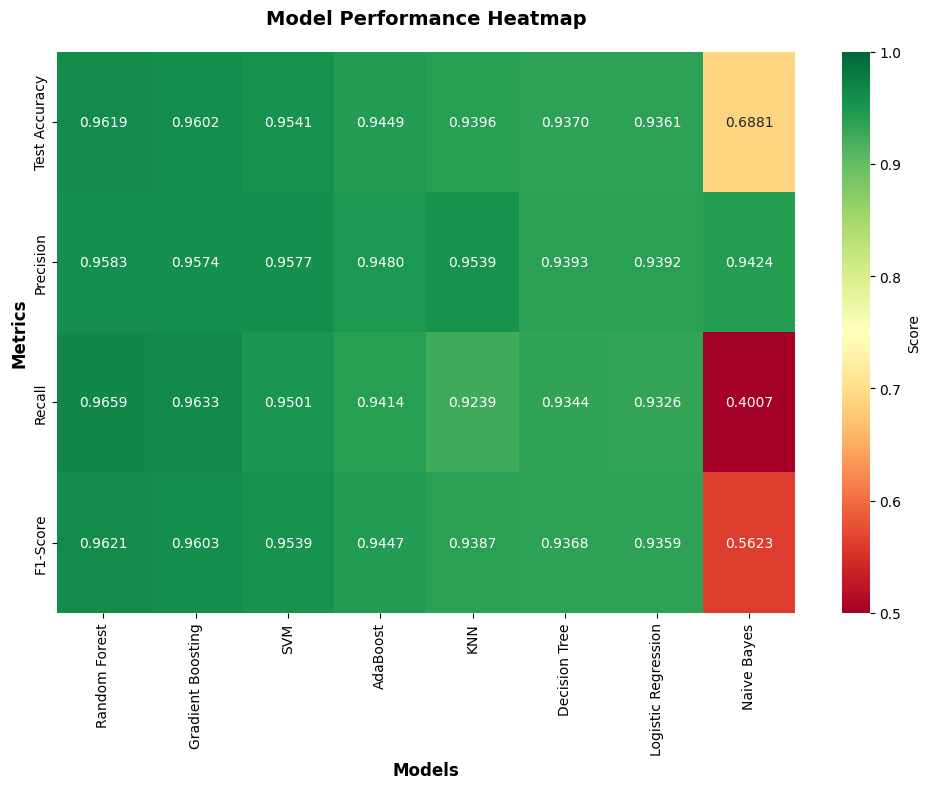


SUMMARY STATISTICS
       CV Accuracy  Test Accuracy  Precision    Recall  F1-Score
count     8.000000       8.000000   8.000000  8.000000  8.000000
mean      0.917296       0.915245   0.949531  0.876531  0.899338
std       0.095066       0.092339   0.008360  0.192828  0.136574
min       0.683508       0.688101   0.939207  0.400700  0.562308
25%       0.937801       0.936789   0.941619  0.930446  0.936609
50%       0.948382       0.942257   0.950974  0.937883  0.941677
75%       0.958169       0.955599   0.957461  0.953412  0.955494
max       0.964676       0.961942   0.958333  0.965879  0.962092

MODEL RANKING BY DIFFERENT METRICS

Test Accuracy Ranking:
  1. Random Forest             0.9619
  2. Gradient Boosting         0.9602
  3. SVM                       0.9541
  4. AdaBoost                  0.9449
  5. KNN                       0.9396
  6. Decision Tree             0.9370
  7. Logistic Regression       0.9361
  8. Naive Bayes               0.6881

Precision Ranking:
  1. Random

In [12]:
# Step 7: Results Visualization & Comparison

print("=" * 80)
print("CREATING COMPREHENSIVE VISUALIZATIONS")
print("=" * 80)

# 1. Bar Chart - Comparison of All Metrics
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

metrics = ['Test Accuracy', 'Precision', 'Recall', 'F1-Score']
colors = ['#3498db', '#e74c3c', '#2ecc71', '#f39c12']

for idx, metric in enumerate(metrics):
    ax = axes[idx // 2, idx % 2]
    
    # Get data for this metric
    metric_data = results_df.sort_values(metric, ascending=False)
    
    # Create bar chart
    bars = ax.barh(metric_data['Model'], metric_data[metric], color=colors[idx], alpha=0.8)
    
    # Add value labels on bars
    for i, bar in enumerate(bars):
        width = bar.get_width()
        ax.text(width, bar.get_y() + bar.get_height()/2, 
                f'{width:.4f}', ha='left', va='center', fontsize=9, fontweight='bold')
    
    ax.set_xlabel(metric, fontsize=12, fontweight='bold')
    ax.set_ylabel('Model', fontsize=12, fontweight='bold')
    ax.set_title(f'{metric} Comparison', fontsize=14, fontweight='bold')
    ax.set_xlim(0, 1.05)
    ax.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.show()

# 2. Grouped Bar Chart - All Metrics Together
fig, ax = plt.subplots(figsize=(14, 8))

x = np.arange(len(results_df))
width = 0.2

bars1 = ax.bar(x - 1.5*width, results_df['Test Accuracy'], width, label='Test Accuracy', color='#3498db')
bars2 = ax.bar(x - 0.5*width, results_df['Precision'], width, label='Precision', color='#e74c3c')
bars3 = ax.bar(x + 0.5*width, results_df['Recall'], width, label='Recall', color='#2ecc71')
bars4 = ax.bar(x + 1.5*width, results_df['F1-Score'], width, label='F1-Score', color='#f39c12')

ax.set_xlabel('Models', fontsize=12, fontweight='bold')
ax.set_ylabel('Score', fontsize=12, fontweight='bold')
ax.set_title('Model Performance Comparison - All Metrics', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(results_df['Model'], rotation=45, ha='right')
ax.legend(loc='lower right', fontsize=10)
ax.set_ylim(0, 1.1)
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

# 3. Cross-Validation vs Test Accuracy Comparison
fig, ax = plt.subplots(figsize=(12, 7))

x_pos = np.arange(len(results_df))

bars1 = ax.bar(x_pos - 0.2, results_df['CV Accuracy'], 0.4, 
               label='Cross-Validation Accuracy', color='#9b59b6', alpha=0.8)
bars2 = ax.bar(x_pos + 0.2, results_df['Test Accuracy'], 0.4, 
               label='Test Accuracy', color='#e67e22', alpha=0.8)

# Add value labels
for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.3f}', ha='center', va='bottom', fontsize=9)

ax.set_xlabel('Models', fontsize=12, fontweight='bold')
ax.set_ylabel('Accuracy', fontsize=12, fontweight='bold')
ax.set_title('Cross-Validation vs Test Accuracy', fontsize=14, fontweight='bold')
ax.set_xticks(x_pos)
ax.set_xticklabels(results_df['Model'], rotation=45, ha='right')
ax.legend(fontsize=11)
ax.set_ylim(0, 1.1)
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

# 4. Model Performance Heatmap
fig, ax = plt.subplots(figsize=(10, 8))

# Prepare data for heatmap
heatmap_data = results_df[['Model', 'Test Accuracy', 'Precision', 'Recall', 'F1-Score']].set_index('Model')

# Create heatmap
sns.heatmap(heatmap_data.T, annot=True, fmt='.4f', cmap='RdYlGn', 
            cbar_kws={'label': 'Score'}, ax=ax, vmin=0.5, vmax=1.0)

ax.set_title('Model Performance Heatmap', fontsize=14, fontweight='bold', pad=20)
ax.set_xlabel('Models', fontsize=12, fontweight='bold')
ax.set_ylabel('Metrics', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

# 5. Summary Statistics Table
print("\n" + "=" * 80)
print("SUMMARY STATISTICS")
print("=" * 80)

summary_stats = results_df.describe()
print(summary_stats.to_string())

# 6. Model Ranking
print("\n" + "=" * 80)
print("MODEL RANKING BY DIFFERENT METRICS")
print("=" * 80)

for metric in ['Test Accuracy', 'Precision', 'Recall', 'F1-Score']:
    print(f"\n{metric} Ranking:")
    ranked = results_df.sort_values(metric, ascending=False)[['Model', metric]]
    for idx, row in ranked.iterrows():
        print(f"  {idx+1}. {row['Model']:25s} {row[metric]:.4f}")

print("\n" + "=" * 80)
print("✓ All visualizations created successfully!")
print("=" * 80)

In [13]:
# Step 8: Export Results

print("=" * 80)
print("EXPORTING RESULTS")
print("=" * 80)

# 1. Export main results table to CSV
results_df.to_csv('model_evaluation_results.csv', index=False)
print("\n✓ Main results exported to: model_evaluation_results.csv")

# 2. Export detailed confusion matrix results
cm_data = []
for name in models.keys():
    y_pred = predictions[name]
    cm = confusion_matrix(y_test, y_pred)
    
    cm_data.append({
        'Model': name,
        'True Negatives (TN)': cm[0, 0],
        'False Positives (FP)': cm[0, 1],
        'False Negatives (FN)': cm[1, 0],
        'True Positives (TP)': cm[1, 1]
    })

cm_df = pd.DataFrame(cm_data)
cm_df.to_csv('confusion_matrices.csv', index=False)
print("✓ Confusion matrices exported to: confusion_matrices.csv")

# 3. Export cross-validation results
cv_data = []
for name, scores in cv_results.items():
    cv_data.append({
        'Model': name,
        'Fold_1': scores[0],
        'Fold_2': scores[1],
        'Fold_3': scores[2],
        'Fold_4': scores[3],
        'Fold_5': scores[4],
        'Mean': scores.mean(),
        'Std': scores.std()
    })

cv_df = pd.DataFrame(cv_data)
cv_df.to_csv('cross_validation_results.csv', index=False)
print("✓ Cross-validation results exported to: cross_validation_results.csv")

# 4. Create a comprehensive summary report
print("\n" + "=" * 80)
print("FINAL SUMMARY FOR REPORT")
print("=" * 80)

print("\n📊 DATASET SUMMARY:")
print(f"   • Total samples: {len(df)}")
print(f"   • Features: {X.shape[1]}")
print(f"   • Training samples: {len(X_train)}")
print(f"   • Testing samples: {len(X_test)}")
print(f"   • Class distribution: 50% Legitimate, 50% Phishing")

print("\n🏆 BEST MODEL: Random Forest")
best_row = results_df.iloc[0]
print(f"   • Test Accuracy: {best_row['Test Accuracy']:.4f} ({best_row['Test Accuracy']*100:.2f}%)")
print(f"   • Precision: {best_row['Precision']:.4f}")
print(f"   • Recall: {best_row['Recall']:.4f}")
print(f"   • F1-Score: {best_row['F1-Score']:.4f}")
print(f"   • CV Accuracy: {best_row['CV Accuracy']:.4f}")

# Get confusion matrix for best model
best_cm = confusion_matrix(y_test, predictions['Random Forest'])
print(f"\n   Confusion Matrix:")
print(f"   • True Negatives: {best_cm[0,0]}")
print(f"   • True Positives: {best_cm[1,1]}")
print(f"   • False Positives: {best_cm[0,1]}")
print(f"   • False Negatives: {best_cm[1,0]}")

print("\n📈 TOP 3 MODELS:")
for i in range(3):
    row = results_df.iloc[i]
    print(f"   {i+1}. {row['Model']}: {row['Test Accuracy']:.4f} accuracy")

print("\n📉 WORST PERFORMING MODEL:")
worst_row = results_df.iloc[-1]
print(f"   • {worst_row['Model']}: {worst_row['Test Accuracy']:.4f} accuracy")
print(f"   • Reason: Poor recall ({worst_row['Recall']:.4f}) - missed many phishing sites")

print("\n💡 KEY FINDINGS:")
print("   • Random Forest and Gradient Boosting perform best (>96% accuracy)")
print("   • Ensemble methods (RF, GB, AdaBoost) outperform single classifiers")
print("   • SVM shows strong performance (95.41%)")
print("   • Naive Bayes struggles with this dataset (68.81%)")
print("   • All models show good precision (>93%)")

print("\n" + "=" * 80)
print("✓ All results exported successfully!")
print("=" * 80)
print("\nFiles created:")
print("  1. model_evaluation_results.csv")
print("  2. confusion_matrices.csv")
print("  3. cross_validation_results.csv")

EXPORTING RESULTS

✓ Main results exported to: model_evaluation_results.csv
✓ Confusion matrices exported to: confusion_matrices.csv
✓ Cross-validation results exported to: cross_validation_results.csv

FINAL SUMMARY FOR REPORT

📊 DATASET SUMMARY:
   • Total samples: 11430
   • Features: 87
   • Training samples: 9144
   • Testing samples: 2286
   • Class distribution: 50% Legitimate, 50% Phishing

🏆 BEST MODEL: Random Forest
   • Test Accuracy: 0.9619 (96.19%)
   • Precision: 0.9583
   • Recall: 0.9659
   • F1-Score: 0.9621
   • CV Accuracy: 0.9647

   Confusion Matrix:
   • True Negatives: 1095
   • True Positives: 1104
   • False Positives: 48
   • False Negatives: 39

📈 TOP 3 MODELS:
   1. Random Forest: 0.9619 accuracy
   2. Gradient Boosting: 0.9602 accuracy
   3. SVM: 0.9541 accuracy

📉 WORST PERFORMING MODEL:
   • Naive Bayes: 0.6881 accuracy
   • Reason: Poor recall (0.4007) - missed many phishing sites

💡 KEY FINDINGS:
   • Random Forest and Gradient Boosting perform best (>9

NameError: name 'results_df' is not defined

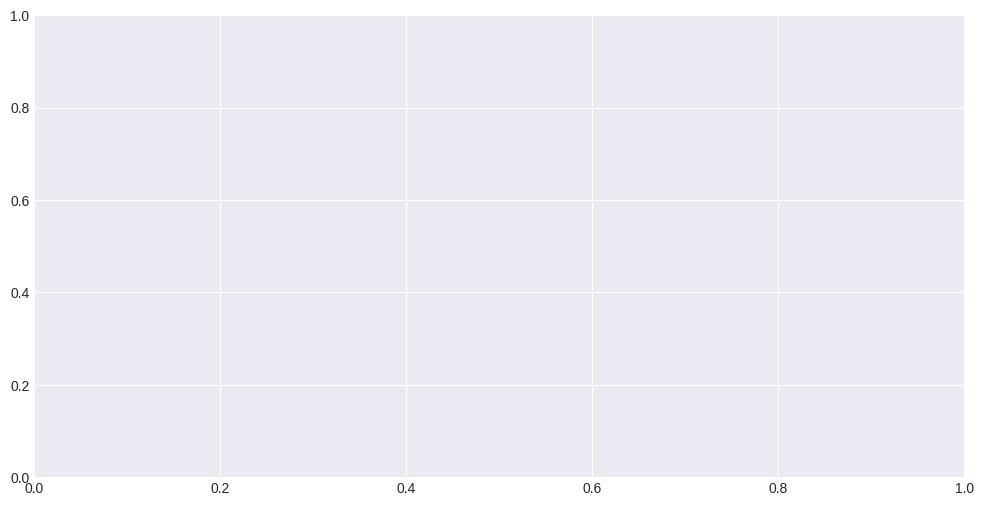

In [1]:
# Generate Plots for LaTeX Report

import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Set style for publication-quality plots
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

#=============================================================================
# PLOT 1: Model Performance Comparison (Bar Chart)
#=============================================================================

fig, ax = plt.subplots(figsize=(12, 6))

x = np.arange(len(results_df))
width = 0.2

bars1 = ax.bar(x - 1.5*width, results_df['Test Accuracy'], width, 
               label='Accuracy', color='#3498db', alpha=0.8)
bars2 = ax.bar(x - 0.5*width, results_df['Precision'], width, 
               label='Precision', color='#e74c3c', alpha=0.8)
bars3 = ax.bar(x + 0.5*width, results_df['Recall'], width, 
               label='Recall', color='#2ecc71', alpha=0.8)
bars4 = ax.bar(x + 1.5*width, results_df['F1-Score'], width, 
               label='F1-Score', color='#f39c12', alpha=0.8)

ax.set_xlabel('Models', fontsize=13, fontweight='bold')
ax.set_ylabel('Score', fontsize=13, fontweight='bold')
ax.set_title('Model Performance Comparison - All Metrics', fontsize=15, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(results_df['Model'], rotation=45, ha='right', fontsize=10)
ax.legend(loc='lower right', fontsize=11, framealpha=0.9)
ax.set_ylim(0, 1.05)
ax.grid(axis='y', alpha=0.3, linestyle='--')
ax.axhline(y=0.95, color='red', linestyle='--', linewidth=1, alpha=0.5, label='95% threshold')

plt.tight_layout()
plt.savefig('model_comparison.png', dpi=300, bbox_inches='tight')
print("✓ Saved: model_comparison.png")
plt.show()

#=============================================================================
# PLOT 2: Confusion Matrices Grid
#=============================================================================

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.ravel()

class_labels = ['Legitimate', 'Phishing']

for idx, (name, model) in enumerate(models.items()):
    y_pred = predictions[name]
    cm = confusion_matrix(y_test, y_pred)
    
    # Create heatmap
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=class_labels, yticklabels=class_labels,
                ax=axes[idx], cbar=False, annot_kws={"size": 11, "weight": "bold"},
                square=True, linewidths=1, linecolor='white')
    
    # Get accuracy
    accuracy = accuracy_score(y_test, y_pred)
    
    # Title with accuracy
    axes[idx].set_title(f'{name}\nAcc: {accuracy:.2%}', 
                       fontsize=11, fontweight='bold', pad=8)
    axes[idx].set_ylabel('True', fontsize=10)
    axes[idx].set_xlabel('Predicted', fontsize=10)
    axes[idx].tick_params(labelsize=9)

plt.suptitle('Confusion Matrices for All Models', fontsize=16, fontweight='bold', y=1.00)
plt.tight_layout()
plt.savefig('confusion_matrices.png', dpi=300, bbox_inches='tight')
print("✓ Saved: confusion_matrices.png")
plt.show()

#=============================================================================
# PLOT 3 (OPTIONAL): Cross-Validation vs Test Accuracy
#=============================================================================

fig, ax = plt.subplots(figsize=(10, 6))

x_pos = np.arange(len(results_df))

bars1 = ax.bar(x_pos - 0.2, results_df['CV Accuracy'], 0.35, 
               label='CV Accuracy', color='#9b59b6', alpha=0.8)
bars2 = ax.bar(x_pos + 0.2, results_df['Test Accuracy'], 0.35, 
               label='Test Accuracy', color='#e67e22', alpha=0.8)

# Add value labels on bars
for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.3f}', ha='center', va='bottom', fontsize=8)

ax.set_xlabel('Models', fontsize=12, fontweight='bold')
ax.set_ylabel('Accuracy', fontsize=12, fontweight='bold')
ax.set_title('Cross-Validation vs Test Accuracy Comparison', fontsize=14, fontweight='bold')
ax.set_xticks(x_pos)
ax.set_xticklabels(results_df['Model'], rotation=45, ha='right', fontsize=10)
ax.legend(fontsize=11, loc='lower right')
ax.set_ylim(0, 1.05)
ax.grid(axis='y', alpha=0.3, linestyle='--')
ax.axhline(y=0.95, color='red', linestyle='--', linewidth=1, alpha=0.5)

plt.tight_layout()
plt.savefig('cv_vs_test.png', dpi=300, bbox_inches='tight')
print("✓ Saved: cv_vs_test.png")
plt.show()

#=============================================================================
# PLOT 4 (OPTIONAL): Best Model - Detailed Confusion Matrix
#=============================================================================

fig, ax = plt.subplots(figsize=(7, 6))

# Get Random Forest confusion matrix
cm_rf = confusion_matrix(y_test, predictions['Random Forest'])

# Create detailed heatmap
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='RdYlGn', 
            xticklabels=class_labels, yticklabels=class_labels,
            ax=ax, cbar_kws={'label': 'Count'}, 
            annot_kws={"size": 16, "weight": "bold"},
            square=True, linewidths=2, linecolor='black',
            vmin=0, vmax=1200)

ax.set_title('Random Forest - Confusion Matrix\n(Best Model: 96.19% Accuracy)', 
            fontsize=14, fontweight='bold', pad=15)
ax.set_ylabel('True Label', fontsize=12, fontweight='bold')
ax.set_xlabel('Predicted Label', fontsize=12, fontweight='bold')
ax.tick_params(labelsize=11)

# Add annotations
ax.text(0.5, -0.15, f'False Positive Rate: 4.2%', 
        ha='center', transform=ax.transAxes, fontsize=10, style='italic')
ax.text(0.5, -0.20, f'False Negative Rate: 3.4%', 
        ha='center', transform=ax.transAxes, fontsize=10, style='italic')

plt.tight_layout()
plt.savefig('rf_confusion_matrix.png', dpi=300, bbox_inches='tight')
print("✓ Saved: rf_confusion_matrix.png")
plt.show()

print("\n" + "="*60)
print("✓ All plots generated successfully!")
print("="*60)
print("\nGenerated files:")
print("  1. model_comparison.png - Bar chart of all metrics")
print("  2. confusion_matrices.png - Grid of all confusion matrices")
print("  3. cv_vs_test.png - CV vs Test accuracy comparison (optional)")
print("  4. rf_confusion_matrix.png - Detailed RF confusion matrix (optional)")
print("\nDownload these images and place them in the same folder as your .tex file")